# Fit a CSTR, design the next experiment, then optimize the flow rate

This notebook carries **one** kinetic model through three different jobs:

1. **Regression** — estimate the rate constants of a series reaction from steady-state
   CSTR data, with uncertainties.
2. **Model-based design of experiments (MBDoE)** — use the fitted model to pick the
   *next* flow rate that most sharpens those estimates.
3. **Optimization** — hold the refined parameters fixed and find the flow rate that
   maximizes the outlet concentration of the intermediate.

The three jobs differ only in **which quantities are free and what is being optimized**.
The physics is written once, as a plain function, and reused unchanged. For the
statistical background see {cite:t}`Bard1974` and {cite:t}`Biegler2010`; for MBDoE
see {cite:t}`Franceschini2008` and {cite:t}`Atkinson2007`, with the original
non-linear design argument in {cite:t}`BoxLucas1959`.

:::{note}
The MBDoE section needs the optional plugin: `pip install discopt-doe`.
:::


In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import matplotlib.pyplot as plt
import numpy as np

import discopt.modeling as dm
from discopt import doe
from discopt.estimate import Experiment, ExperimentModel, estimate_parameters

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.autolayout": True})

## 1. The reactor model

A single isothermal CSTR of volume $V$ fed pure **A** at concentration $C_{A0}$ and
volumetric flow rate $F$, with the first-order series reaction

$$\mathrm{A} \xrightarrow{k_1} \mathrm{B} \xrightarrow{k_2} \mathrm{C}.$$

Writing the residence time $\tau = V/F$, the steady-state mass balances
$F(C_{A0}-C_A) = V k_1 C_A$ and $F(0-C_B) = V(k_2 C_B - k_1 C_A)$ solve in closed form:

$$C_A = \frac{C_{A0}}{1+k_1\tau}, \qquad
  C_B = \frac{k_1 \tau\, C_A}{1+k_2\tau}, \qquad
  C_C = C_{A0} - C_A - C_B .$$

**This is the only place the physics is written.** The function below is used for all
three jobs — generating data, fitting, designing experiments, and optimizing. It works
on floats *and* on discopt `Expression` objects, because the arithmetic operators are
overloaded; that is what makes the model reusable without a rewrite. See
{cite:t}`Fogler2016` for the reactor-design background.

Using the closed form rather than leaving $C_A, C_B$ as implicitly-constrained
variables is deliberate: the Fisher information is built from $\partial y/\partial\theta$
by autodiff through the **response expression**, so the responses have to be explicit
functions of the parameters.

In [2]:
V = 1.0        # reactor volume, L
CA0 = 2.0      # feed concentration of A, mol/L


def cstr_outlet(F, k1, k2, CA0=CA0, V=V):
    """Steady-state CSTR outlet concentrations for A -> B -> C.

    Accepts floats/arrays (for simulation) or discopt Expressions (for the
    models below) -- the same code serves every stage of this notebook.

    Returns
    -------
    (CA, CB, CC)
    """
    tau = V / F
    CA = CA0 / (1.0 + k1 * tau)
    CB = k1 * tau * CA / (1.0 + k2 * tau)
    return CA, CB, CA0 - CA - CB

### Ground truth and synthetic measurements

We invent a "true" reactor so the fitted values can be checked. In a real study these
are unknown; everything downstream only ever sees `observe()`'s noisy output.

In [3]:
K1_TRUE, K2_TRUE = 1.50, 0.40    # 1/min
SIGMA = 0.03                      # measurement std dev, mol/L

rng = np.random.default_rng(7)


def observe(flow_rates):
    """Run the (pretend) experiment: true model + Gaussian measurement noise."""
    F = np.atleast_1d(np.asarray(flow_rates, dtype=float))
    CA, CB, _ = cstr_outlet(F, K1_TRUE, K2_TRUE)
    return (CA + SIGMA * rng.standard_normal(CA.shape),
            CB + SIGMA * rng.standard_normal(CB.shape))


# A first campaign: five flow rates over a fairly narrow, conveniently-fast range.
F_initial = np.array([0.6, 0.9, 1.3, 1.9, 2.6])
CA_obs, CB_obs = observe(F_initial)

print(f"{'F (L/min)':>10} {'tau (min)':>10} {'CA obs':>9} {'CB obs':>9}")
for F, a, b in zip(F_initial, CA_obs, CB_obs):
    print(f"{F:10.2f} {V / F:10.3f} {a:9.4f} {b:9.4f}")

 F (L/min)  tau (min)    CA obs    CB obs
      0.60      1.667    0.5715    0.8274
      0.90      1.111    0.7590    0.8672
      1.30      0.769    0.9203    0.8595
      1.90      0.526    1.0909    0.7141
      2.60      0.385    1.2547    0.6155


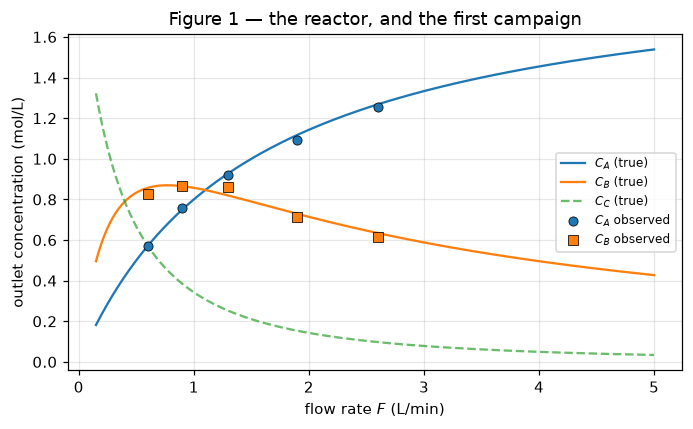

In [4]:
F_dense = np.linspace(0.15, 5.0, 400)
CA_t, CB_t, CC_t = cstr_outlet(F_dense, K1_TRUE, K2_TRUE)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(F_dense, CA_t, label="$C_A$ (true)", color="C0")
ax.plot(F_dense, CB_t, label="$C_B$ (true)", color="C1")
ax.plot(F_dense, CC_t, label="$C_C$ (true)", color="C2", ls="--", alpha=0.7)
ax.plot(F_initial, CA_obs, "o", color="C0", mec="k", mew=0.5, label="$C_A$ observed")
ax.plot(F_initial, CB_obs, "s", color="C1", mec="k", mew=0.5, label="$C_B$ observed")
ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("outlet concentration (mol/L)")
ax.set_title("Figure 1 — the reactor, and the first campaign")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 2. Estimate $k_1$ and $k_2$

`discopt.estimate` wants an `Experiment` whose `create_model()` returns an
`ExperimentModel` labelling what is unknown, what was controlled, and what was
measured. The unknown parameters are ordinary decision `Variable`s — that is how the
least-squares problem gets something to optimize over.

Each flow rate contributes two responses ($C_A$ and $C_B$), each built by calling the
same `cstr_outlet`.

In [5]:
class CSTRCampaign(Experiment):
    """One response pair per flow rate -- the estimation view of the model."""

    def __init__(self, flow_rates):
        self.flow_rates = np.asarray(flow_rates, dtype=float)

    def create_model(self, **kwargs):
        m = dm.Model("cstr_fit")
        k1 = m.continuous("k1", lb=1e-3, ub=20.0)
        k2 = m.continuous("k2", lb=1e-3, ub=20.0)

        responses, errors = {}, {}
        for i, F in enumerate(self.flow_rates):
            CA, CB, _ = cstr_outlet(float(F), k1, k2)   # <- the same function
            responses[f"CA_{i}"], errors[f"CA_{i}"] = CA, SIGMA
            responses[f"CB_{i}"], errors[f"CB_{i}"] = CB, SIGMA

        return ExperimentModel(
            model=m,
            unknown_parameters={"k1": k1, "k2": k2},
            design_inputs={},
            responses=responses,
            measurement_error=errors,
        )


def pack(CA_values, CB_values, offset=0):
    """Observations -> the {response_name: value} dict estimate_parameters wants."""
    data = {}
    for i, (a, b) in enumerate(zip(CA_values, CB_values), start=offset):
        data[f"CA_{i}"] = float(a)
        data[f"CB_{i}"] = float(b)
    return data


data_1 = pack(CA_obs, CB_obs)
fit_1 = estimate_parameters(
    CSTRCampaign(F_initial), data_1, initial_guess={"k1": 0.5, "k2": 1.0}
)
print(fit_1.summary())

Parameter Estimation Results
            k1 =      1.52528  ± 0.04033  [1.432, 1.618]
            k2 =     0.417587  ± 0.0284  [0.3521, 0.4831]
     Objective = 4.04437
         N obs = 10
       FIM det = 1.016e+06
      FIM cond = 3.746


### Parameters and uncertainties after campaign 1

`EstimationResult` carries the covariance (the inverse Fisher information at the
solution), so standard errors, 95% confidence intervals and the parameter correlation
all come straight off the fit.

In [6]:
def parameter_table(fit, truth=None, title=""):
    """Render an estimate +/- uncertainty table as Markdown."""
    from IPython.display import Markdown

    se, ci = fit.standard_errors, fit.confidence_intervals
    head = "| parameter | estimate | std. error | 95% CI | rel. error |"
    rule = "|---|---:|---:|:---:|---:|"
    if truth is not None:
        head = head[:-1] + " true | error |"
        rule = rule[:-1] + "---:|---:|"
    rows = [head, rule]
    for name in fit.parameter_names:
        val, s = fit.parameters[name], se[name]
        lo, hi = ci[name]
        row = (f"| ${name[0]}_{name[1]}$ | {val:.4f} | {s:.4f} | "
               f"[{lo:.4f}, {hi:.4f}] | {100 * s / abs(val):.2f}% |")
        if truth is not None:
            t = truth[name]
            row = row[:-1] + f" {t:.4f} | {val - t:+.4f} |"
        rows.append(row)
    body = "\n".join(rows)
    return Markdown(f"**{title}**\n\n{body}\n\n"
                    f"*Weighted SSE = {fit.objective:.4f} on "
                    f"{fit.n_observations} observations; "
                    f"corr($k_1$,$k_2$) = {fit.correlation_matrix[0, 1]:+.3f}.*")


TRUTH = {"k1": K1_TRUE, "k2": K2_TRUE}
parameter_table(fit_1, TRUTH, "Table 1 — campaign 1 (5 flow rates, 10 observations)")

**Table 1 — campaign 1 (5 flow rates, 10 observations)**

| parameter | estimate | std. error | 95% CI | rel. error  true | error |
|---|---:|---:|:---:|---:---:|---:|
| $k_1$ | 1.5253 | 0.0403 | [1.4323, 1.6183] | 2.64%  1.5000 | +0.0253 |
| $k_2$ | 0.4176 | 0.0284 | [0.3521, 0.4831] | 6.80%  0.4000 | +0.0176 |

*Weighted SSE = 4.0444 on 10 observations; corr($k_1$,$k_2$) = +0.500.*

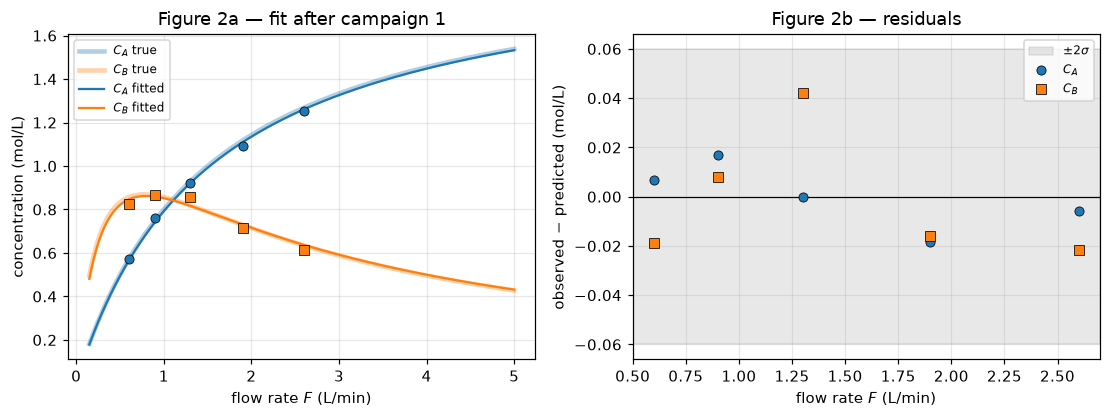

In [7]:
CA_f1, CB_f1, _ = cstr_outlet(F_dense, fit_1.parameters["k1"], fit_1.parameters["k2"])

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))

ax = axes[0]
ax.plot(F_dense, CA_t, color="C0", alpha=0.35, lw=3, label="$C_A$ true")
ax.plot(F_dense, CB_t, color="C1", alpha=0.35, lw=3, label="$C_B$ true")
ax.plot(F_dense, CA_f1, color="C0", ls="-", label="$C_A$ fitted")
ax.plot(F_dense, CB_f1, color="C1", ls="-", label="$C_B$ fitted")
ax.plot(F_initial, CA_obs, "o", color="C0", mec="k", mew=0.5)
ax.plot(F_initial, CB_obs, "s", color="C1", mec="k", mew=0.5)
ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("concentration (mol/L)")
ax.set_title("Figure 2a — fit after campaign 1")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# residuals
CA_p, CB_p, _ = cstr_outlet(F_initial, fit_1.parameters["k1"], fit_1.parameters["k2"])
ax = axes[1]
ax.axhline(0, color="k", lw=0.8)
ax.axhspan(-2 * SIGMA, 2 * SIGMA, color="grey", alpha=0.18, label=r"$\pm 2\sigma$")
ax.plot(F_initial, CA_obs - CA_p, "o", color="C0", mec="k", mew=0.5, label="$C_A$")
ax.plot(F_initial, CB_obs - CB_p, "s", color="C1", mec="k", mew=0.5, label="$C_B$")
ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("observed $-$ predicted (mol/L)")
ax.set_title("Figure 2b — residuals")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

### What the uncertainty looks like

The covariance matrix defines a joint confidence region. Its shape is the thing MBDoE
attacks: a long, tilted ellipse means the data constrain some *combination* of $k_1$ and
$k_2$ well, and another combination badly.

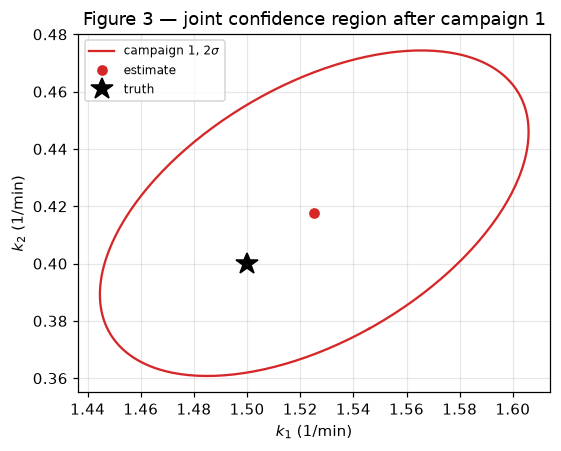

correlation matrix:
 [[1.     0.4995]
 [0.4995 1.    ]]


In [8]:
def confidence_ellipse(cov, center, n_std=2.0, n_points=256):
    """Points on the ``n_std``-sigma ellipse of a 2x2 covariance matrix."""
    vals, vecs = np.linalg.eigh(np.asarray(cov, dtype=float))
    t = np.linspace(0.0, 2.0 * np.pi, n_points)
    circle = np.stack([np.cos(t), np.sin(t)])
    pts = vecs @ (n_std * np.sqrt(np.maximum(vals, 0.0))[:, None] * circle)
    return pts[0] + center[0], pts[1] + center[1]


c1 = (fit_1.parameters["k1"], fit_1.parameters["k2"])
ex, ey = confidence_ellipse(fit_1.covariance, c1)

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.plot(ex, ey, color="C3", label=r"campaign 1, $2\sigma$")
ax.plot(*c1, "o", color="C3", label="estimate")
ax.plot(K1_TRUE, K2_TRUE, "*", ms=15, color="k", label="truth")
ax.set_xlabel("$k_1$ (1/min)")
ax.set_ylabel("$k_2$ (1/min)")
ax.set_title("Figure 3 — joint confidence region after campaign 1")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print("correlation matrix:\n", np.round(fit_1.correlation_matrix, 4))

## 3. Model-based design of the next experiment

Which flow rate should we run next? MBDoE answers this by asking which condition adds
the most **Fisher information** about the parameters {cite:p}`Franceschini2008`. The
information from a design is

$$\mathrm{FIM} = J^\top \Sigma^{-1} J, \qquad J_{ij} = \frac{\partial y_i}{\partial \theta_j},$$

evaluated at the current best estimate $\hat\theta$ — sensitivities that
`discopt-doe` gets by autodiff, not finite differences. We maximize
$\det(\mathrm{FIM}_{\text{prior}} + \mathrm{FIM}_{\text{new}})$ (the **D-optimal**
criterion, which shrinks the volume of the ellipse in Figure 3), passing the campaign-1
information as the prior so the design is genuinely *sequential*.

This needs a second view of the same model: one reactor, with $F$ as a **design
variable** rather than baked in as a constant. Same `cstr_outlet` call.

In [9]:
class CSTRDesignPoint(Experiment):
    """A single reactor with F as a DESIGN VARIABLE -- the MBDoE view."""

    def create_model(self, **kwargs):
        m = dm.Model("cstr_design")
        k1 = m.continuous("k1", lb=1e-3, ub=20.0)
        k2 = m.continuous("k2", lb=1e-3, ub=20.0)
        F = m.continuous("F", lb=0.05, ub=5.0)

        CA, CB, _ = cstr_outlet(F, k1, k2)              # <- still the same function

        return ExperimentModel(
            model=m,
            unknown_parameters={"k1": k1, "k2": k2},
            design_inputs={"F": F},
            responses={"CA": CA, "CB": CB},
            measurement_error={"CA": SIGMA, "CB": SIGMA},
        )


design_point = CSTRDesignPoint()
F_BOUNDS = (0.05, 5.0)

best = doe.optimal_experiment(
    design_point,
    param_values=fit_1.parameters,
    design_bounds={"F": F_BOUNDS},
    criterion="determinant",
    prior_fim=fit_1.fim,       # sequential: build on what campaign 1 already told us
    seed=1,
)
F_next = float(best.design["F"])
print(f"D-optimal next flow rate: F = {F_next:.4f} L/min  (tau = {V / F_next:.3f} min)")
print(f"log det(FIM) there      : {best.criterion_value:.4f}")

D-optimal next flow rate: F = 0.3116 L/min  (tau = 3.210 min)
log det(FIM) there      : 14.4537


### Why that flow rate?

Scanning the criterion over the whole feasible range shows the design landscape rather
than just its argmax — worth plotting, because a flat optimum means the exact
recommendation hardly matters, while a sharp one means it does.

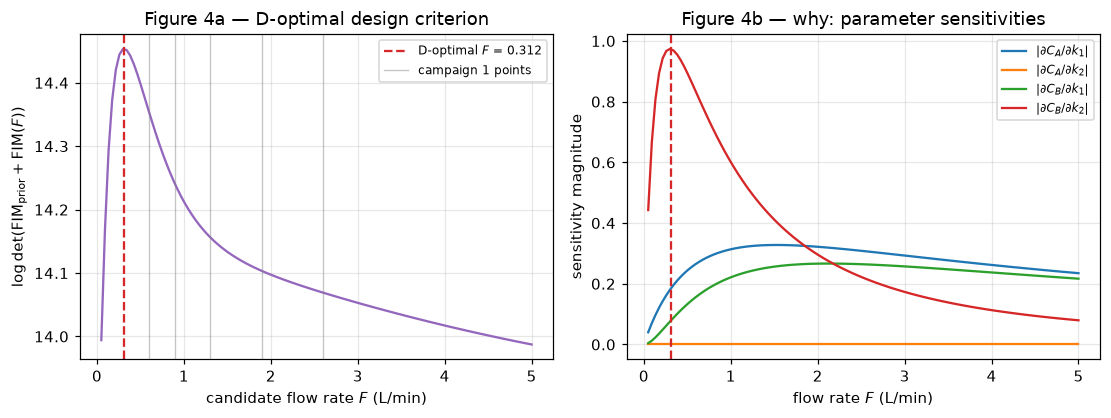

In [10]:
F_grid = np.linspace(F_BOUNDS[0], F_BOUNDS[1], 120)
logdet = np.array([
    np.log(np.linalg.det(
        doe.compute_fim(design_point, fit_1.parameters, {"F": float(F)},
                        prior_fim=fit_1.fim).fim))
    for F in F_grid
])

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))

ax = axes[0]
ax.plot(F_grid, logdet, color="C4")
ax.axvline(F_next, color="C3", ls="--", label=f"D-optimal $F$ = {F_next:.3f}")
for F in F_initial:
    ax.axvline(F, color="grey", alpha=0.45, lw=0.9)
ax.plot([], [], color="grey", alpha=0.45, lw=0.9, label="campaign 1 points")
ax.set_xlabel("candidate flow rate $F$ (L/min)")
ax.set_ylabel(r"$\log\det(\mathrm{FIM}_{\rm prior} + \mathrm{FIM}(F))$")
ax.set_title("Figure 4a — D-optimal design criterion")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# the sensitivities that drive it
ax = axes[1]
J = np.array([
    doe.compute_fim(design_point, fit_1.parameters, {"F": float(F)}).jacobian
    for F in F_grid
])
names = doe.compute_fim(design_point, fit_1.parameters, {"F": 1.0}).response_names
for r, resp in enumerate(names):
    for p, par in enumerate(["k_1", "k_2"]):
        ax.plot(F_grid, np.abs(J[:, r, p]),
                label=rf"$|\partial {resp[0]}_{resp[1]}/\partial {par}|$")
ax.axvline(F_next, color="C3", ls="--")
ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("sensitivity magnitude")
ax.set_title("Figure 4b — why: parameter sensitivities")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

The recommendation sits at a **low** flow rate — a long residence time. That is
where the slow second step has time to act, so $C_B$ becomes sensitive to $k_2$; the
first campaign, run fast, mostly saw $k_1$. The criterion rises steeply toward the
low-$F$ boundary and is flat over the region campaign 1 already sampled, which is the
quantitative version of "another point at $F\approx2$ would tell us almost nothing".

## 4. Run the designed experiment and refit

We run one experiment at the recommended condition, append it to the data, and refit
with all six flow rates.

In [11]:
CA_new, CB_new = observe([F_next])
F_refined = np.append(F_initial, F_next)

data_2 = dict(data_1)
data_2.update(pack(CA_new, CB_new, offset=len(F_initial)))

fit_2 = estimate_parameters(
    CSTRCampaign(F_refined), data_2, initial_guess=fit_1.parameters
)
print(fit_2.summary())

Parameter Estimation Results
            k1 =       1.5129  ± 0.03738  [1.43, 1.596]
            k2 =     0.404171  ± 0.02083  [0.3577, 0.4506]
     Objective = 4.81937
         N obs = 12
       FIM det = 2.037e+06
      FIM cond = 4.614


In [12]:
parameter_table(fit_2, TRUTH,
                "Table 2 — after the designed experiment (6 flow rates, 12 observations)")

**Table 2 — after the designed experiment (6 flow rates, 12 observations)**

| parameter | estimate | std. error | 95% CI | rel. error  true | error |
|---|---:|---:|:---:|---:---:|---:|
| $k_1$ | 1.5129 | 0.0374 | [1.4296, 1.5962] | 2.47%  1.5000 | +0.0129 |
| $k_2$ | 0.4042 | 0.0208 | [0.3577, 0.4506] | 5.15%  0.4000 | +0.0042 |

*Weighted SSE = 4.8194 on 12 observations; corr($k_1$,$k_2$) = +0.436.*

In [13]:
from IPython.display import Markdown

rows = ["| parameter | SE before | SE after | change | 95% CI width before | after |",
        "|---|---:|---:|---:|---:|---:|"]
for name in fit_1.parameter_names:
    s1, s2 = fit_1.standard_errors[name], fit_2.standard_errors[name]
    w1 = fit_1.confidence_intervals[name][1] - fit_1.confidence_intervals[name][0]
    w2 = fit_2.confidence_intervals[name][1] - fit_2.confidence_intervals[name][0]
    rows.append(f"| ${name[0]}_{name[1]}$ | {s1:.5f} | {s2:.5f} | "
                f"{100 * (s2 - s1) / s1:+.1f}% | {w1:.4f} | {w2:.4f} |")
d1, d2 = np.linalg.det(fit_1.fim), np.linalg.det(fit_2.fim)
Markdown("**Table 3 — what the single designed experiment bought**\n\n"
         + "\n".join(rows)
         + f"\n\n*det(FIM): {d1:.4g} → {d2:.4g} ({d2 / d1:.2f}×). "
           f"One extra run, chosen by the model.*")

**Table 3 — what the single designed experiment bought**

| parameter | SE before | SE after | change | 95% CI width before | after |
|---|---:|---:|---:|---:|---:|
| $k_1$ | 0.04033 | 0.03738 | -7.3% | 0.1860 | 0.1666 |
| $k_2$ | 0.02840 | 0.02083 | -26.6% | 0.1310 | 0.0928 |

*det(FIM): 1.016e+06 → 2.037e+06 (2.00×). One extra run, chosen by the model.*

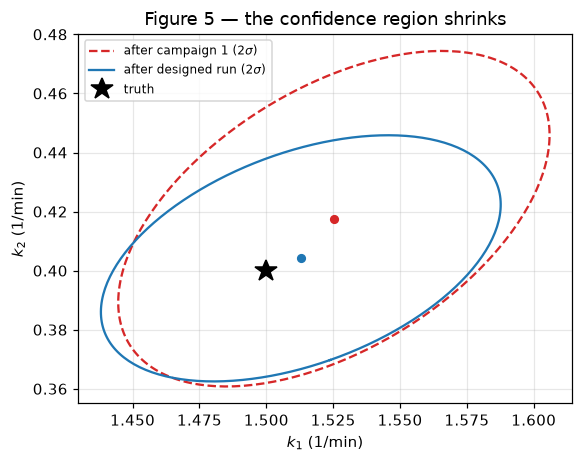

In [14]:
c2 = (fit_2.parameters["k1"], fit_2.parameters["k2"])
ex2, ey2 = confidence_ellipse(fit_2.covariance, c2)

fig, ax = plt.subplots(figsize=(5.4, 4.3))
ax.plot(ex, ey, color="C3", ls="--", label=r"after campaign 1 ($2\sigma$)")
ax.plot(*c1, "o", color="C3", ms=5)
ax.plot(ex2, ey2, color="C0", label=r"after designed run ($2\sigma$)")
ax.plot(*c2, "o", color="C0", ms=5)
ax.plot(K1_TRUE, K2_TRUE, "*", ms=15, color="k", label="truth")
ax.set_xlabel("$k_1$ (1/min)")
ax.set_ylabel("$k_2$ (1/min)")
ax.set_title("Figure 5 — the confidence region shrinks")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 5. Optimize the flow rate

Now the third job. We want the flow rate maximizing the outlet concentration of the
intermediate **B** — with the rate constants now *known* (fixed at their estimates)
and $F$ *free*. That is the exact mirror image of the estimation problem, where the
$k$'s were free and $F$ was fixed at whatever we happened to run.

So we reuse the **same `ExperimentModel`** built for the design step. Only two things
change:

* the objective becomes $\max C_B$, and
* the free/fixed partition flips — `Model.fixed` pins $k_1, k_2$ for the duration of
  the solve and restores them on exit.

Scoping the fix matters: `lb == ub` *is* how a fixed variable is expressed, and bounds
are re-read at every solve, so a fix left behind by accident would silently redefine
the next problem and still report `optimal`. The context manager makes that
unrepresentable.

In [15]:
em = CSTRDesignPoint().create_model()
model = em.model
k1_var, k2_var = em.unknown_parameters["k1"], em.unknown_parameters["k2"]
F_var = em.design_inputs["F"]

model.maximize(em.responses["CB"])          # new objective on the existing model

with model.fixed({k1_var: fit_2.parameters["k1"],
                  k2_var: fit_2.parameters["k2"]}):
    opt = model.solve(time_limit=60)

F_opt = float(opt.value(F_var))
CB_opt = float(opt.objective)

print(f"status        : {opt.status}   (gap certified: {opt.gap_certified})")
print(f"nodes         : {opt.node_count}")
print(f"optimal F*    : {F_opt:.4f} L/min   (tau* = {V / F_opt:.4f} min)")
print(f"max outlet C_B: {CB_opt:.4f} mol/L")
print(f"fix scopes closed -> depths {(k1_var.fix_depth, k2_var.fix_depth)}")

status        : optimal   (gap certified: True)
nodes         : 5
optimal F*    : 0.7820 L/min   (tau* = 1.2788 min)
max outlet C_B: 0.8692 mol/L
fix scopes closed -> depths (0, 0)


### Check it against the closed form

This particular problem has an analytic optimum, so the numerical answer is
checkable rather than merely plausible. Maximizing
$C_B(\tau) = C_{A0}k_1\tau / \big[(1+k_1\tau)(1+k_2\tau)\big]$ over $\tau$ gives

$$\tau^\star = \frac{1}{\sqrt{k_1 k_2}}, \qquad F^\star = V\sqrt{k_1 k_2}.$$

In [16]:
k1_hat, k2_hat = fit_2.parameters["k1"], fit_2.parameters["k2"]
F_closed = V * np.sqrt(k1_hat * k2_hat)
_, CB_closed, _ = cstr_outlet(F_closed, k1_hat, k2_hat)

print(f"solver     : F* = {F_opt:.9f}   C_B* = {CB_opt:.9f}")
print(f"closed form: F* = {F_closed:.9f}   C_B* = {CB_closed:.9f}")
print(f"difference : dF = {abs(F_opt - F_closed):.2e}   dC_B = {abs(CB_opt - CB_closed):.2e}")

assert abs(F_opt - F_closed) < 1e-6, "solver disagrees with the closed form"
assert abs(CB_opt - CB_closed) < 1e-9
print("\nagreement verified")

solver     : F* = 0.781965493   C_B* = 0.869232488
closed form: F* = 0.781965494   C_B* = 0.869232488
difference : dF = 5.97e-10   dC_B = 1.13e-14

agreement verified


### How much does parameter uncertainty move the optimum?

The optimum is computed from *estimates*, so it inherits their uncertainty. Propagating
the fitted covariance through $F^\star = V\sqrt{k_1 k_2}$ by sampling gives an honest
interval on the recommended set point — the practical payoff of having done the DoE.

In [17]:
samples = rng.multivariate_normal([k1_hat, k2_hat], fit_2.covariance, size=4000)
samples = samples[(samples > 0).all(axis=1)]
F_star_samples = V * np.sqrt(samples[:, 0] * samples[:, 1])
lo, hi = np.percentile(F_star_samples, [2.5, 97.5])

# the same propagation using the *pre-DoE* covariance, for comparison
s1 = rng.multivariate_normal(list(c1), fit_1.covariance, size=4000)
s1 = s1[(s1 > 0).all(axis=1)]
F_star_1 = V * np.sqrt(s1[:, 0] * s1[:, 1])
lo1, hi1 = np.percentile(F_star_1, [2.5, 97.5])

print(f"F* from campaign-1 parameters : {np.mean(F_star_1):.4f} "
      f"[{lo1:.4f}, {hi1:.4f}]  (width {hi1 - lo1:.4f})")
print(f"F* after the designed run     : {np.mean(F_star_samples):.4f} "
      f"[{lo:.4f}, {hi:.4f}]  (width {hi - lo:.4f})")
print(f"true optimum                  : {V * np.sqrt(K1_TRUE * K2_TRUE):.4f}")

F* from campaign-1 parameters : 0.7982 [0.7286, 0.8643]  (width 0.1357)
F* after the designed run     : 0.7813 [0.7323, 0.8312]  (width 0.0989)
true optimum                  : 0.7746


## 6. The answer

Outlet concentrations over the whole flow-rate range, at the fitted parameters, with
the optimum marked.

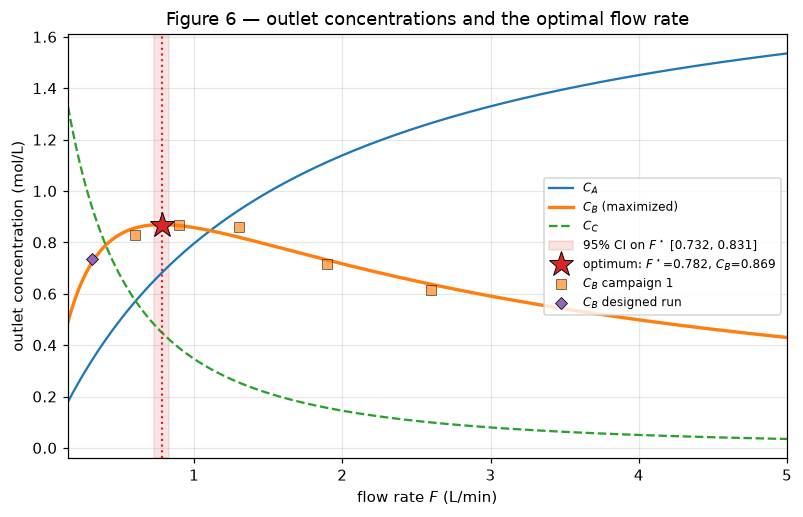

In [18]:
CA_f, CB_f, CC_f = cstr_outlet(F_dense, k1_hat, k2_hat)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(F_dense, CA_f, color="C0", label="$C_A$")
ax.plot(F_dense, CB_f, color="C1", lw=2.2, label="$C_B$ (maximized)")
ax.plot(F_dense, CC_f, color="C2", ls="--", label="$C_C$")

ax.axvspan(lo, hi, color="C3", alpha=0.13,
           label=f"95% CI on $F^\\star$ [{lo:.3f}, {hi:.3f}]")
ax.axvline(F_opt, color="C3", ls=":", lw=1.4)
ax.plot([F_opt], [CB_opt], "*", ms=17, color="C3", mec="k", mew=0.6, zorder=5,
        label=f"optimum: $F^\\star$={F_opt:.3f}, $C_B$={CB_opt:.3f}")

ax.plot(F_initial, CB_obs, "s", color="C1", mec="k", mew=0.5, alpha=0.65,
        label="$C_B$ campaign 1")
ax.plot([F_next], CB_new, "D", color="C4", mec="k", mew=0.5,
        label="$C_B$ designed run")

ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("outlet concentration (mol/L)")
ax.set_title("Figure 6 — outlet concentrations and the optimal flow rate")
ax.legend(fontsize=8, loc="center right")
ax.grid(alpha=0.3)
ax.set_xlim(F_dense[0], F_dense[-1])
plt.show()

In [19]:
from IPython.display import Markdown

Markdown(f"""**Table 4 — summary**

| quantity | value |
|---|---:|
| $k_1$ | {k1_hat:.4f} $\\pm$ {fit_2.standard_errors['k1']:.4f} 1/min (true {K1_TRUE}) |
| $k_2$ | {k2_hat:.4f} $\\pm$ {fit_2.standard_errors['k2']:.4f} 1/min (true {K2_TRUE}) |
| designed flow rate | {F_next:.4f} L/min |
| information gain | det(FIM) $\\times${np.linalg.det(fit_2.fim) / np.linalg.det(fit_1.fim):.2f} |
| **optimal flow rate $F^\\star$** | **{F_opt:.4f} L/min** (95% CI [{lo:.3f}, {hi:.3f}]) |
| **maximum outlet $C_B$** | **{CB_opt:.4f} mol/L** ({100 * CB_opt / CA0:.1f}% of feed $C_{{A0}}$) |
| optimal residence time | {V / F_opt:.4f} min |
| solver status | `{opt.status}`, gap certified: {opt.gap_certified} |
""")

**Table 4 — summary**

| quantity | value |
|---|---:|
| $k_1$ | 1.5129 $\pm$ 0.0374 1/min (true 1.5) |
| $k_2$ | 0.4042 $\pm$ 0.0208 1/min (true 0.4) |
| designed flow rate | 0.3116 L/min |
| information gain | det(FIM) $\times$2.00 |
| **optimal flow rate $F^\star$** | **0.7820 L/min** (95% CI [0.732, 0.831]) |
| **maximum outlet $C_B$** | **0.8692 mol/L** (43.5% of feed $C_{A0}$) |
| optimal residence time | 1.2788 min |
| solver status | `optimal`, gap certified: True |


## What to take away

One model served three jobs, and the only things that changed between them were the
objective and which quantities were free:

| job | free | fixed | objective |
|---|---|---|---|
| regression | $k_1, k_2$ | $F$ (at each measured condition) | min weighted SSE |
| MBDoE | $F$ | $k_1,k_2$ (at $\hat\theta$) | max $\det \mathrm{FIM}$ |
| optimization | $F$ | $k_1,k_2$ (at $\hat\theta$) | max $C_B$ |

Two practical points. First, the designed experiment was chosen where the model said
information *was*, not where it was convenient to run, and one such run tightened $k_2$
far more than another point in the original range would have — the standard MBDoE
result {cite:p}`Franceschini2008,BoxLucas1959`. Second, the optimum is a function of
estimated parameters, so it carries their uncertainty; reporting $F^\star$ without the
interval in Figure 6 would overstate what the data support {cite:p}`Bard1974`.

The MBDoE loop here was run one round by hand to keep each step visible.
`discopt.doe.sequential_doe` automates the whole cycle when you can hand it a callable
that runs an experiment.

Full citation details for the works above are on the [references](../references.md) page.